# 0003 - Longest Substring Without Repeating Characters

Neste notebook, vamos resolver o problema **Longest Substring Without Repeating Characters** de forma didática, saindo da abordagem mais simples até chegar à solução ideal.

A ideia é que este material sirva para estudo, revisão e futura publicação em um **Jupyter Book**. Por isso, vamos priorizar:

- explicações claras;
- código legível;
- testes com `assert`;
- comparação entre abordagens;
- gráficos conceituais de complexidade.


## Enunciado resumido

Dada uma string `s`, encontre o comprimento da **maior substring** sem caracteres repetidos.

Exemplos do enunciado:

- `s = "abcabcbb"` -> resposta `3`, porque a maior substring válida é `"abc"`.
- `s = "bbbbb"` -> resposta `1`, porque qualquer substring com mais de um caractere repete `"b"`.
- `s = "pwwkew"` -> resposta `3`, porque uma resposta válida é `"wke"`.

Restrições:

- `0 <= len(s) <= 5 * 10^4`
- a string pode conter letras, dígitos, símbolos e espaços.


## Intuição geral

A pergunta parece simples, mas esconde um detalhe importante: não queremos apenas saber se uma substring tem repetição, e sim encontrar **a maior entre todas**.

A ideia central é observar como uma substring válida se comporta:

- enquanto os caracteres forem diferentes, podemos continuar expandindo a substring;
- quando um caractere repetido aparece, a substring atual deixa de ser válida;
- então precisamos decidir como explorar o restante da string sem repetir trabalho demais.

Esse raciocínio nos leva naturalmente a três níveis de solução:

1. testar tudo de forma direta;
2. testar tudo, mas parando mais cedo quando a repetição aparece;
3. manter uma janela deslizante para evitar recomputações desnecessárias.


## Substring vs. subsequence

Antes de seguir, vale reforçar uma diferença que costuma gerar confusão:

- **substring**: caracteres **contíguos** na string original;
- **subsequence**: caracteres na mesma ordem, mas **sem precisar ser contíguos**.

Neste problema, a palavra correta é **substring**. Então não podemos pular caracteres no meio.

Exemplo com `"pwwkew"`:

- `"wke"` é uma substring válida;
- `"pwke"` seria uma subsequence, mas **não** uma substring.

Essa distinção é crucial porque muda completamente o tipo de estratégia que faz sentido.


## Dependências e ambiente

Vamos usar apenas bibliotecas comuns do ecossistema Python para visualização e organização dos gráficos.

- `matplotlib`
- `seaborn`
- `pandas`

Os gráficos desta aula são **conceituais**: eles ilustram a ordem de crescimento assintótico das abordagens, não medem benchmark real.


In [1]:
from __future__ import annotations

from typing import Callable

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titleweight"] = "bold"


## Solução 1 — Força bruta

A primeira ideia é a mais direta possível:

1. gerar todas as substrings possíveis;
2. verificar se cada uma possui caracteres repetidos;
3. guardar o maior comprimento encontrado.

Essa abordagem é correta porque, se examinarmos todas as substrings, certamente encontraremos a melhor resposta. O problema é o custo: ela faz muito trabalho repetido.

### Como pensar nela

Se a string for `"abcabcbb"`, podemos imaginar várias substrings candidatas:

- `"a"`, `"ab"`, `"abc"`, `"abca"`, ...
- `"b"`, `"bc"`, `"bca"`, ...
- `"c"`, `"ca"`, ...

Para cada uma, precisamos conferir se há repetição interna.

### Por que funciona?

Porque a resposta final é o maior comprimento entre todas as substrings válidas. Se todas as substrings são testadas, nenhuma solução possível fica de fora.

### Onde ela é fraca?

Ela recalcula muitas coisas:

- gera substrings em excesso;
- reconstrói estruturas auxiliares para checar repetição;
- repete verificações de caracteres várias vezes.


In [2]:
def length_of_longest_substring_bruteforce(s: str) -> int:
    """
    Calcula o comprimento da maior substring sem caracteres repetidos usando
    força bruta.

    A estratégia percorre todas as substrings possíveis da string de entrada
    e verifica, uma a uma, se os caracteres daquela substring são todos únicos.
    Entre todas as substrings válidas, retornamos o maior comprimento encontrado.

    Parâmetros:
    ----------
    s : str
        String de entrada. Em contextos didáticos, aceitamos qualquer string
        Python válida. Se o valor informado não for uma string, uma exceção é
        levantada para deixar o comportamento explícito.

    Retorno:
    -------
    int
        Comprimento da maior substring de `s` sem caracteres repetidos.

    Exceções:
    --------
    TypeError
        Levantada quando `s` não for uma string.

    Exemplos de uso:
    --------
    >>> length_of_longest_substring_bruteforce("abcabcbb")
    3
    >>> length_of_longest_substring_bruteforce("bbbbb")
    1
    >>> length_of_longest_substring_bruteforce("")
    0
    """
    if not isinstance(s, str):
        raise TypeError("s deve ser uma string")

    maior = 0
    n = len(s)

    for inicio in range(n):
        for fim in range(inicio + 1, n + 1):
            substring = s[inicio:fim]
            if len(set(substring)) == len(substring):
                maior = max(maior, len(substring))

    return maior


### Complexidade da Solução 1

- **Tempo**: `O(n^3)`.
  - existem `O(n^2)` substrings;
  - para cada substring, checamos unicidade em `O(n)` no pior caso.
- **Espaço**: `O(n)` no pior caso, por causa do conjunto usado para verificar caracteres de uma substring.

Em termos intuitivos: é uma solução correta, mas cara, porque examina combinações demais e repete verificações desnecessárias.


In [3]:
casos_de_teste = [
    ("", 0),
    ("a", 1),
    ("bbbbb", 1),
    ("abcabcbb", 3),
    ("pwwkew", 3),
    ("dvdf", 3),
    ("abba", 2),
    (" ", 1),
    ("au", 2),
    ("anviaj", 5),
]


def testar_implementacao(func: Callable[[str], int], nome: str) -> None:
    for entrada, esperado in casos_de_teste:
        resultado = func(entrada)
        assert resultado == esperado, (
            f"{nome} falhou para {entrada!r}: esperado {esperado}, obtido {resultado}"
        )
    print(f"{nome}: todos os testes passaram.")


testar_implementacao(length_of_longest_substring_bruteforce, "Solução 1 - Força bruta")


Solução 1 - Força bruta: todos os testes passaram.


### Traço mental rápido

Vamos olhar apenas para a ideia geral em `"abcabcbb"`:

- `"a"` é válida, comprimento 1;
- `"ab"` é válida, comprimento 2;
- `"abc"` é válida, comprimento 3;
- `"abca"` deixa de ser válida, porque `"a"` se repete.

A força bruta descobre isso testando todas as combinações possíveis.


## Solução 2 — Melhorada

Agora vamos melhorar a ideia anterior sem abandonar completamente a exploração de substrings.

A melhoria é simples e muito útil:

- escolhemos um ponto inicial;
- expandimos a substring caractere por caractere;
- assim que uma repetição aparece, paramos de expandir aquela tentativa.

Isso evita continuar examinando substrings que já sabemos que serão inválidas.

### O que melhora?

Na força bruta pura, geramos muitas substrings e depois verificamos unicidade do zero.
Aqui, para cada ponto de início, mantemos um conjunto com os caracteres já vistos e interrompemos cedo quando há repetição.

### O que ainda limita essa solução?

Mesmo com a poda, ainda precisamos tentar vários pontos de início. Ou seja, ela continua sendo quadrática no pior caso.


In [4]:
def length_of_longest_substring_improved(s: str) -> int:
    """
    Calcula o comprimento da maior substring sem caracteres repetidos usando
    uma versão melhorada da força bruta.

    A ideia é escolher cada posição como início de uma substring e expandi-la
    enquanto os caracteres continuarem únicos. Assim que um caractere repetido
    aparece, interrompemos a expansão daquela tentativa, porque qualquer
    extensão futura também continuará inválida.

    Parâmetros:
    ----------
    s : str
        String de entrada.

    Retorno:
    -------
    int
        Comprimento da maior substring sem repetição.

    Exceções:
    --------
    TypeError
        Levantada quando `s` não for uma string.

    Exemplos de uso:
    --------
    >>> length_of_longest_substring_improved("abcabcbb")
    3
    >>> length_of_longest_substring_improved("pwwkew")
    3
    >>> length_of_longest_substring_improved("abba")
    2
    """
    if not isinstance(s, str):
        raise TypeError("s deve ser uma string")

    maior = 0
    n = len(s)

    for inicio in range(n):
        vistos: set[str] = set()
        for fim in range(inicio, n):
            caractere = s[fim]
            if caractere in vistos:
                break
            vistos.add(caractere)
            maior = max(maior, fim - inicio + 1)

    return maior


### Complexidade da Solução 2

- **Tempo**: `O(n^2)` no pior caso.
  - para cada posição inicial, podemos expandir a janela até o fim da string;
  - a interrupção antecipada reduz trabalho, mas não elimina o pior caso quadrático.
- **Espaço**: `O(min(n, k))`, onde `k` é o tamanho do conjunto de caracteres relevantes dentro da expansão atual.

Intuitivamente, a solução ficou melhor porque não reconstrói substrings completas o tempo todo. Ainda assim, ela repete muitas expansões a partir de posições diferentes.


In [5]:
testar_implementacao(length_of_longest_substring_improved, "Solução 2 - Melhorada")


Solução 2 - Melhorada: todos os testes passaram.


### Traço mental rápido

Para `"pwwkew"`:

- começando em `"p"`, conseguimos `"pw"`, mas paramos em `"pww"`;
- começando em `"w"`, conseguimos `"w"` e depois `"wk"` e `"wke"`;
- começando em outras posições, também fazemos expansões curtas.

A diferença para a força bruta é que não insistimos em continuar expandindo uma sequência que já sabemos que quebrou a regra.


## Gráfico conceitual de complexidade

Os gráficos abaixo são ilustrativos. Eles não medem tempo real de execução; servem apenas para mostrar visualmente como cresce o custo assintótico das abordagens.

Esse tipo de visualização é útil em material didático porque ajuda a comparar ordens de grandeza sem depender do hardware da máquina ou de microbenchmarks instáveis.


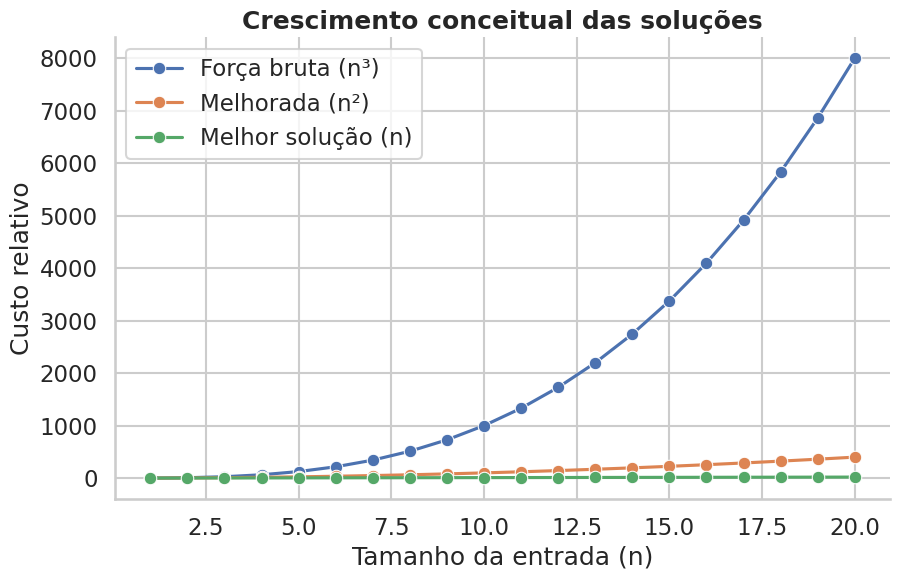

In [6]:
n = list(range(1, 21))
complexidade_df = pd.DataFrame(
    {
        "n": n,
        "Força bruta (n³)": [x**3 for x in n],
        "Melhorada (n²)": [x**2 for x in n],
        "Melhor solução (n)": n,
    }
)

complexidade_long = complexidade_df.melt(id_vars="n", var_name="Abordagem", value_name="Custo conceitual")

ax = sns.lineplot(
    data=complexidade_long,
    x="n",
    y="Custo conceitual",
    hue="Abordagem",
    marker="o",
)
ax.set_title("Crescimento conceitual das soluções")
ax.set_xlabel("Tamanho da entrada (n)")
ax.set_ylabel("Custo relativo")
plt.legend(title="")
plt.show()


## Solução 3 — Melhor solução possível

Agora chegamos à abordagem ideal para este problema: **sliding window** com dois ponteiros e um dicionário para lembrar a última posição de cada caractere.

Essa é a solução clássica porque resolve o problema em tempo linear.

### Ideia principal

Vamos manter uma janela `s[esquerda:direita+1]` com caracteres únicos.

- `direita` avança caractere por caractere;
- se o caractere atual já apareceu dentro da janela, movemos `esquerda` para depois da última ocorrência desse caractere;
- dessa forma, a janela volta a ser válida sem precisar reprocessar tudo do zero.

### Por que isso é eficiente?

Porque cada caractere entra e sai da janela de forma controlada. Em vez de testar muitas substrings independentes, mantemos uma única janela dinâmica que evolui ao longo da string.

### Exemplo com `"abcabcbb"`

- janela começa vazia;
- lê `a`, depois `b`, depois `c` -> janela `"abc"`;
- lê outro `a` -> repetição, então movemos a borda esquerda para depois do `a` anterior;
- continuamos repetindo esse processo até o fim.

### Exemplo com `"pwwkew"`

- `"pw"` é válida;
- ao ler o segundo `w`, deslocamos a borda esquerda para manter unicidade;
- mais adiante, conseguimos construir `"wke"`, que tem tamanho 3.


In [7]:
def length_of_longest_substring_sliding_window(s: str) -> int:
    """
    Calcula o comprimento da maior substring sem caracteres repetidos usando
    sliding window (janela deslizante) e rastreamento da última posição vista
    de cada caractere.

    A função percorre a string uma única vez. A cada caractere, mantemos uma
    janela válida sem repetição. Quando encontramos um caractere que já existe
    dentro da janela atual, deslocamos o início da janela para a posição logo
    após a última ocorrência desse caractere.

    Parâmetros:
    ----------
    s : str
        String de entrada.

    Retorno:
    -------
    int
        Comprimento da maior substring sem caracteres repetidos.

    Exceções:
    --------
    TypeError
        Levantada quando `s` não for uma string.

    Exemplos de uso:
    --------
    >>> length_of_longest_substring_sliding_window("abcabcbb")
    3
    >>> length_of_longest_substring_sliding_window("pwwkew")
    3
    >>> length_of_longest_substring_sliding_window("dvdf")
    3
    """
    if not isinstance(s, str):
        raise TypeError("s deve ser uma string")

    ultima_posicao: dict[str, int] = {}
    esquerda = 0
    maior = 0

    for direita, caractere in enumerate(s):
        if caractere in ultima_posicao and ultima_posicao[caractere] >= esquerda:
            esquerda = ultima_posicao[caractere] + 1
        ultima_posicao[caractere] = direita
        maior = max(maior, direita - esquerda + 1)

    return maior


### Complexidade da Solução 3

- **Tempo**: `O(n)`.
  - cada posição da string é processada uma vez;
  - o ponteiro esquerdo também avança de forma monotônica.
- **Espaço**: `O(min(n, k))`, onde `k` é o número de caracteres distintos que já apareceram.

Intuitivamente, essa é a melhor solução porque não recomeça do zero para cada substring candidata. Ela reaproveita informação sobre onde cada caractere apareceu pela última vez.


In [8]:
testar_implementacao(length_of_longest_substring_sliding_window, "Solução 3 - Sliding window")


Solução 3 - Sliding window: todos os testes passaram.


### Traço manual da janela

Vamos acompanhar `"abcabcbb"` em alto nível:

| direita | caractere | esquerda antes | ação | esquerda depois | janela atual | melhor |
|---|---|---:|---|---:|---|---:|
| 0 | `a` | 0 | adiciona | 0 | `a` | 1 |
| 1 | `b` | 0 | adiciona | 0 | `ab` | 2 |
| 2 | `c` | 0 | adiciona | 0 | `abc` | 3 |
| 3 | `a` | 0 | repetiu `a`, move a esquerda | 1 | `bca` | 3 |
| 4 | `b` | 1 | repetiu `b`, move a esquerda | 2 | `cab` | 3 |
| 5 | `c` | 2 | repetiu `c`, move a esquerda | 3 | `abc` | 3 |

A lógica é sempre a mesma: quando a repetição aparece dentro da janela atual, movemos a borda esquerda para restaurar a propriedade de unicidade.


In [9]:
def trace_sliding_window(s: str) -> pd.DataFrame:
    """Gera um traço didático da execução da solução de janela deslizante."""
    ultima_posicao: dict[str, int] = {}
    esquerda = 0
    melhor = 0
    linhas = []

    for direita, caractere in enumerate(s):
        esquerda_antes = esquerda
        acao = "adiciona"
        if caractere in ultima_posicao and ultima_posicao[caractere] >= esquerda:
            esquerda = ultima_posicao[caractere] + 1
            acao = f"repetiu {caractere!r}, move a esquerda"
        ultima_posicao[caractere] = direita
        melhor = max(melhor, direita - esquerda + 1)
        linhas.append(
            {
                "direita": direita,
                "caractere": caractere,
                "esquerda antes": esquerda_antes,
                "ação": acao,
                "esquerda depois": esquerda,
                "janela atual": s[esquerda : direita + 1],
                "melhor": melhor,
            }
        )

    return pd.DataFrame(linhas)


trace_sliding_window("abcabcbb")


,direita,caractere,esquerda antes,ação,esquerda depois,janela atual,melhor
0,0,a,0,adiciona,0,a,1
1,1,b,0,adiciona,0,ab,2
2,2,c,0,adiciona,0,abc,3
3,3,a,0,"repetiu 'a', move a esquerda",1,bca,3
4,4,b,1,"repetiu 'b', move a esquerda",2,cab,3
5,5,c,2,"repetiu 'c', move a esquerda",3,abc,3
6,6,b,3,"repetiu 'b', move a esquerda",5,cb,3
7,7,b,5,"repetiu 'b', move a esquerda",7,b,3


## Solução 4 — Versão enxuta para submissão no LeetCode

Agora vamos para a versão mais curta e direta, no formato esperado pelo LeetCode.

Aqui a prioridade é simplicidade e correção. Como já entendemos a lógica na solução 3, podemos reduzir o código ao essencial.

### Observação

Nesta versão, não vamos manter a validação explícita de tipo. No LeetCode, a entrada já vem no formato esperado, então o objetivo é deixar a solução limpa para colar no editor da plataforma.


In [10]:
class Solution:
    def lengthOfLongestSubstring(self, s: str) -> int:
        last_seen: dict[str, int] = {}
        left = 0
        best = 0

        for right, ch in enumerate(s):
            if ch in last_seen and last_seen[ch] >= left:
                left = last_seen[ch] + 1
            last_seen[ch] = right
            best = max(best, right - left + 1)

        return best


In [11]:
solution = Solution()

for entrada, esperado in casos_de_teste:
    resultado = solution.lengthOfLongestSubstring(entrada)
    assert resultado == esperado, (
        f"Versão LeetCode falhou para {entrada!r}: esperado {esperado}, obtido {resultado}"
    )

print("Versão LeetCode: todos os testes passaram.")


Versão LeetCode: todos os testes passaram.


## Comparação entre as abordagens

A tabela abaixo resume o que muda entre as soluções.

| Abordagem | Ideia principal | Tempo | Espaço | Vale em entrevista? | Vale em produção? | Observações |
|---|---|---:|---:|---|---|---|
| Força bruta | Testar todas as substrings e verificar unicidade | `O(n^3)` | `O(n)` | Não, mas ajuda a mostrar raciocínio inicial | Não | Correta, porém muito lenta |
| Melhorada | Expandir a partir de cada início e parar cedo ao repetir | `O(n^2)` | `O(n)` | Sim, como etapa intermediária | Raramente | Boa ponte para a solução final |
| Melhor solução | Sliding window com última posição vista | `O(n)` | `O(n)` | Sim, definitivamente | Sim | É a abordagem ideal |
| Versão enxuta | Mesma lógica da melhor solução, em formato LeetCode | `O(n)` | `O(n)` | Sim | Sim | Pronta para submissão |


## Conclusão final

A evolução das soluções mostra um padrão importante em algoritmos:

- começar com a abordagem mais óbvia ajuda a entender o problema;
- depois, melhorar a estratégia reduz trabalho repetido;
- por fim, uma estrutura apropriada como a **janela deslizante** transforma a ideia em uma solução linear.

### Recomendação prática

- **Para aprender**: estude as três primeiras soluções em ordem, porque elas mostram a evolução do raciocínio.
- **Para entrevista**: apresente a solução 3, explicando por que a janela deslizante resolve o problema de forma eficiente.
- **Para submeter no LeetCode**: use a solução 4, que é a versão enxuta da melhor abordagem.

Se você dominar este problema, estará praticando uma técnica que aparece em muitos outros exercícios de string e arrays.
